# Shelter Dog Adoptability

Amelia Farrell
12/2/24


In [ ]:

# Connecting to google drive
from google.colab import drive
drive.mount('/content/drive')

# Change to the google drive directory
%cd /content/drive/MyDrive/Colab\ Notebooks/DSC550

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive/Colab Notebooks/DSC550


## Introduction

According to the ASPA, about 3.1 Million dogs and 3.2 Million cats are surrendered to shelters each year in the US. Around 920,000 of these animals are euthanized (Pet Statistics, n.d.)1. Thankfully the number of euthanizations have been in decline since 2011 primarily due to an increase in adoptions and returns to original owners.

This decrease is great news for pets in shelters. We would like to continue this decline and eventually get all shelter pets adopted each year. For this analysis, we are going to be focusing on the adoptability traits of dogs. Looking at what traits and factors help a dog get adopted faster. Does ensuring the dog is neutered increase their chances? Do older dogs have less of a chance of being adopted quickly, meaning we should focus more on advertising the benefits of adopting elderly dogs? Keeping the number of euthanizations to a minimum. The faster pets can be adopted, the less chance that they will be euthanized.



1. Pet statistics. (n.d.). ASPCA. https://www.aspca.org/helping-people-pets/shelter-intake-and-surrender/pet-statistics

## Load the dataset and libraries

We will first be loading the dataset and viewing the frist 5 rows to get an understanding of the variables we will be working with.

In [ ]:
# importing libraries needed
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
# loading dataset as a data frame
df = pd.read_csv('labeledTrainData.tsv')
df.head(5)

,Type,Name,Age,Breed1,Breed2,TpyeBreed1,Gender,Color1,Color2,Color3,...,Health,Quantity,Fee,State,RescuerID,VideoAmt,Description,PetID,PhotoAmt,AdoptionSpeed
0,2,No Name Yet,1,265,0,Domestic Medium Hair,1,1,2,0,...,1,1,0,41401,3082c7125d8fb66f7dd4bff4192c8b14,0,I just found it alone yesterday near my apartm...,6296e909a,2,0
1,1,Brisco,1,307,0,Mixed Breed,1,2,7,0,...,1,1,0,41326,fa90fa5b1ee11c86938398b60abc32cb,0,Their pregnant mother was dumped by her irresp...,3422e4906,7,3
2,1,Miko,4,307,0,Mixed Breed,2,1,2,0,...,1,1,150,41401,9238e4f44c71a75282e62f7136c6b240,0,"Good guard dog, very alert, active, obedience ...",5842f1ff5,8,2
3,1,Hunter,1,307,0,Mixed Breed,1,1,0,0,...,1,1,0,41326,95481e953f8aed9ec3d16fc4509537e8,0,This handsome yet cute boy is up for adoption....,850a43f90,3,2
4,1,Siu Pak & Her 6 Puppies,0,307,0,Mixed Breed,2,1,2,7,...,1,6,0,41326,1fba5f6e5480946254590d48f9c5198d,0,Siu Pak just give birth on 13/6/10 to 6puppies...,97aa9eeac,9,3


## Histograms

As we can see from the table above, we can easily plot a histogram of Adoption Speed (average number of days it took for the pet to be adopted) to get an idea of the distribution and any outlires.

Adoption speed
* 0 - Pet was adopted on the same day as it was listed.
* 1 - Pet was adopted between 1 and 7 days (1st week) after being listed.
* 2 - Pet was adopted between 8 and 30 days (1st month) after being listed.
* 3 - Pet was adopted between 31 and 90 days (2nd & 3rd month) after being listed.
* 4 - No adoption after 100 days of being listed. (There are no pets in this dataset that waited between 90 and 100 days).

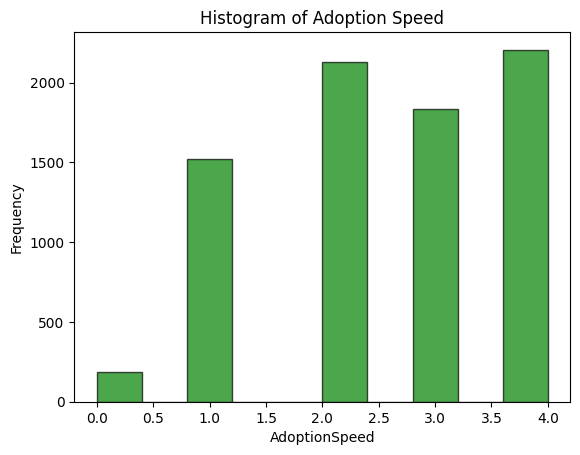

In [ ]:
# Selecting adoption speed column to review the distribution in isolation.
adoption_speed = df['AdoptionSpeed']

# Histogram of AdoptionSpeed
plt.hist(adoption_speed, bins=10, color='green', alpha=0.7, edgecolor='black')

# Adding titles and labels
plt.title('Histogram of Adoption Speed')
plt.xlabel('AdoptionSpeed')
plt.ylabel('Frequency')

# Show the plot
plt.show()

In [ ]:
# Calcuating the Average Adoption Speed
average_adoption_speed = df['AdoptionSpeed'].mean()
print(f"Average Adoption Speed: {average_adoption_speed:.2f} days")

Average Adoption Speed: 2.55 days


We can infer from the Adoption Speed distribution that a small percent of pets get adopted within 1 day. Most get adopted after at least 8 days (lower end of Adoption Speed 2) after being listed. Does the dog's age or nurtured status effect the speed at which they are adopted? We will be looking more into these questions as we go through our analysis.

Next we want to look at the distribution of age. Since we will want to ultimately see how the two variables (Age and Adoption Speed) correlate.

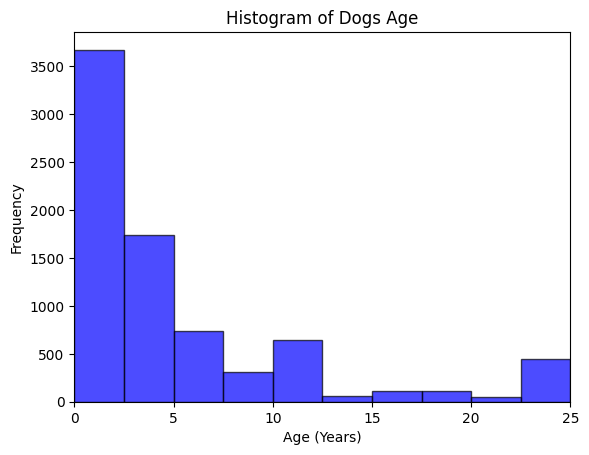

In [ ]:
# Selecting adoption speed column to review the distribution.
age = df['Age']

# Histogram of AdoptionSpeed
plt.hist(age, bins=10, color='blue', alpha=0.7, edgecolor='black')
plt.xlim(0, 25)

# Adding titles and labels
plt.title('Histogram of Dogs Age')
plt.xlabel('Age (Years)')
plt.ylabel('Frequency')

# Show the plot
plt.show()

In [ ]:
# Calcuating the Average Age
average_adoption_speed = df['Age'].mean()
print(f"Average Age in Years: {average_adoption_speed:.2f}")

Average Age in Years: 5.36


Based on our distrubtion, the highest percent of dogs fall under the age of 3.
Knowing this, do younger dogs tend to be adopted faster than dogs over the average age of 5.36? Next we will want to plot a scatter plot next to see the relationship.

## Scatter Plot

Now that we have a better understanding of the distributions of each dog's age and adoption speed. We will want to test our hypothesis that age and adoption speed are highly correlated. With older dogs taking longer to be adopted than  younger dogs (under the average age of 5.63).

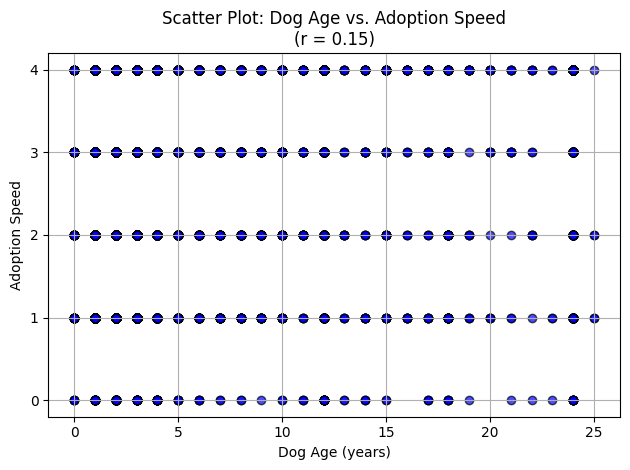

In [ ]:
# Scatter plot of Age vs Adoption Speed
plt.scatter(df['Age'], df['AdoptionSpeed'], color='blue', alpha=0.7, edgecolor='black')

# Calculate the pearson correlation coefficient (r-value)
correlation_agespeed = np.corrcoef(df['Age'], df['AdoptionSpeed'])[0, 1]

# Set the y-axis ticks with a spacing of 1
plt.yticks(range(0, int(df['AdoptionSpeed'].max()) + 1, 1))

# Adding labels and title
plt.title(f'Scatter Plot: Dog Age vs. Adoption Speed\n(r = {correlation:.2f})')
plt.xlabel('Dog Age (years)')
plt.ylabel('Adoption Speed')
plt.grid(True)

# Show the plot
plt.tight_layout()
plt.show()

As we can see in the above scatter plot and correlation coefficient of r=0.15, there is no relationship between Adoption Speed and Age of dog. While this is good news for older dogs, it does not give us a good place to start in regards to increasing the speed of adoption by focusing on marketing for older dogs.

## Bar Charts

Since we discovered that the age of the dog does not impact the speed of adoption, we want to look at how nurturing relates to adoption speed. We can hypothesize that dogs who have already been nurtured have a higher chance of being adopted quickly. Since this reduces the barrier to entry or effort that will be needed for a new or even experienced pet owner. We will look at this relationship using a bar chart separated out buy the average speed of adoption and whether or not the pet is nurtured ('Sterilized' column within the data set).

In [ ]:
# We will frist filter out any rows where 'Sterilized' is unknown (3)
# Pet has been neutered (1 = Yes, 0 = No, 3 = unknown)
nutered_df = df[df['Sterilized'] != 3]

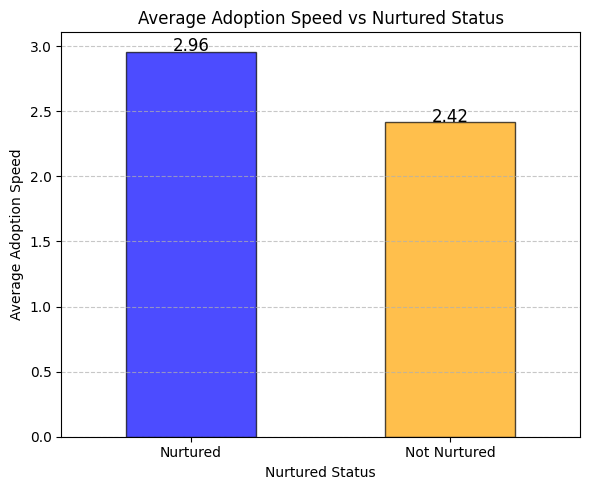

In [ ]:
# Calculate average adoption speed for each nurtured status
average_speed = nutered_df.groupby('Sterilized')['AdoptionSpeed'].mean()

# Plotting
#average_speed.plot(kind='bar', figsize=(6, 5), color=['blue', 'orange'], alpha=0.7, edgecolor='black')
ax = average_speed.plot(kind='bar', figsize=(6, 5), color=['blue', 'orange'], alpha=0.7, edgecolor='black')

# Adding the average values on top of the bars
for i, v in enumerate(average_speed):
    ax.text(i, v + 0.11, f'{v:.2f}', ha='center', va='top', fontsize=12, color='black')

# Customize the plot
plt.title('Average Adoption Speed vs Nurtured Status')
plt.xlabel('Nurtured Status')
plt.ylabel('Average Adoption Speed')
plt.xticks(ticks=[0, 1], labels=['Nurtured', 'Not Nurtured'], rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Show the plot
plt.tight_layout()
plt.show()

In [ ]:
# Calculate the correlation coefficient (r-value)
correlation_nutered = np.corrcoef(nutered_df['Sterilized'], nutered_df['AdoptionSpeed'])[0, 1]
correlation_nutered

-0.1917639607101221

Based on the above bar chart and the Pearson correlation coefficient of -0.19, there is no significant relationship between neutered dogs and speed at which they are adopted. Again, this is great news for the dogs, but not good news for us. It gives us one less variable that we can use to increase the speed of pet adoption and ultimately lower the number of euthanizations.


## Box Plot

While we have proved that neither the dog's age nor nurtured status affects the speed of their adoption. I would now like to look at one more variable, the dog's breed. If the dog's breed makes a large impact on it's adoption speed, we could use this information to understand why and how to address it. Have potential pet parents heard bad things about the breed? Are they not interested due to other factors such as their size or hair length? Before we look into it further, lets plot the top 20 dog breeds in our data set and compare their mean adoption speeds.

In [ ]:
# Calculating the top 20 breeds to help fit the view.
top_breeds = df['TpyeBreed1'].value_counts().head(20).index

# Filter the data to include only the top 20 breeds
filtered_breeds = df[df['TpyeBreed1'].isin(top_breeds)]

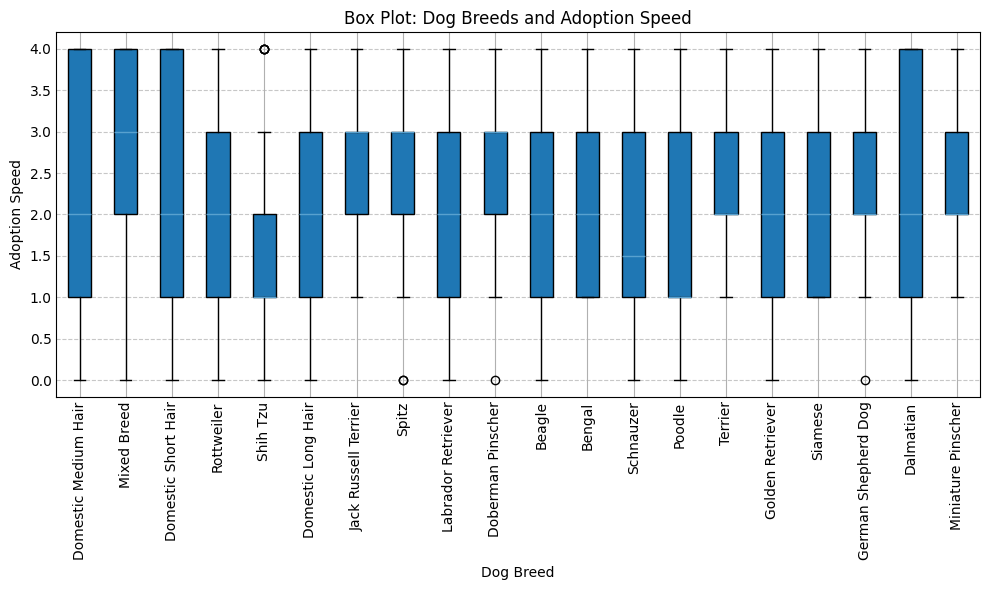

In [ ]:
# Grouping adoption speeds by dog breeds
breed_adoption_speeds = [filtered_breeds[filtered_breeds['TpyeBreed1'] == breed]['AdoptionSpeed'] for breed in filtered_breeds['TpyeBreed1'].unique()]

# Create the box plot
plt.figure(figsize=(10, 6))
plt.boxplot(breed_adoption_speeds, labels=filtered_breeds['TpyeBreed1'].unique(), patch_artist=True)

# Rotate x-axis labels
plt.xticks(rotation=90)

# Customize the plot
plt.title('Box Plot: Dog Breeds and Adoption Speed')
plt.xlabel('Dog Breed')
plt.ylabel('Adoption Speed')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Show the plot
plt.tight_layout()
plt.show()

## Conclusion

We had originally hypothesized that a dog’s age and neutered status affected the adoptability (speed at which they were adopted). However, upon viewing the data in Histograms, Scatter Plots, Bar Charts, and calculating the Pearson correlation coefficient, we came to the conclusion that neither the dog's age or neutered status significantly impacts the speed at which they are adopted. We then looked at how the dog's breed may impact adoptability using a box plot to view the mean adoption speed for the top 20 dog breeds in our data set. This view was the most compelling from the analysis. Upon viewing the box plot, we can see some pattern revealing itself. Noting the mean lowering for the Shih Tuz and raising for the Mixed Breeds. The box plot gave us a great starting place to begin further analysis. If we can identify a specific breed that takes much longer than others to be adopted, it would be the first step at finding a way to increase their adoption speed.

While this short analysis did not give us the answers we thought we would find, it gave us a great place to start. There are still many variables to be analyzed just within our original data set, not to mention other data sources that we can collect and review. Such as post adoption surveys, notes on dog’s temperament, dog's past, how they are with other dogs/kids, etc. The more data we can collect and analyze, the better the chance that we can identify the variables that make the largest impact on adoption speed and address the cause where we can.
